<a href="https://colab.research.google.com/github/Harsh-2404/ebay-customer-behavior-analysis/blob/main/eBay_Customer_Purchasing_Behavior_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# eBay Customer Purchasing Behavior and Product Recommendation Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("eBay.csv")

In [ ]:
#Dataset Shape

df.shape

(800, 24)

In [ ]:
# Column Names

df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency ', 'Recommendation_Helpfulness',
       'Rating_Accuracy ', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas', 'transaction'],
      dtype='object')

In [ ]:
df.dtypes

,0
Timestamp,object
age,int64
Gender,object
Purchase_Frequency,object
Purchase_Categories,object
Personalized_Recommendation_Frequency,object
Browsing_Frequency,object
Product_Search_Method,object
Search_Result_Exploration,object
Customer_Reviews_Importance,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   639 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

In [ ]:
# Missing Values Properly Check

missing = df.isnull().sum()

missing[missing > 0]

,0
Product_Search_Method,161


In [ ]:
# Missing Values Properly Check in Percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

,0
Product_Search_Method,20.125


### Task 1: Data Cleaning and Preparation

***1.1: Remove duplicate or inconsistent survey responses.***

In [ ]:
# Duplicate rows check

duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


#####Inconsistent Survey Responses

In [ ]:
# Identify Inconsistent Survey Responses

# Identify all categorical/text columns in the dataset
text_columns = df.select_dtypes(include="object").columns

# Display the unique response counts for each categorical column
for col in text_columns:
    print("\n---", col, "---")
    print(df[col].value_counts(dropna=False))


--- Timestamp ---
Timestamp
2023/06/07 10:10:26 PM GMT+5:30    6
2023/06/07 9:20:34 AM GMT+5:30     5
2023/06/05 2:21:37 PM GMT+5:30     5
2023/06/08 5:14:30 PM GMT+5:30     5
2023/06/06 7:46:27 PM GMT+5:30     5
                                  ..
2023/06/09 3:22:15 PM GMT+5:30     1
2023/06/05 2:24:22 PM GMT+5:30     1
2023/06/07 9:21:10 PM GMT+5:30     1
2023/06/06 6:38:49 PM GMT+5:30     1
2023/06/11 11:02:55 PM GMT+5:30    1
Name: count, Length: 440, dtype: int64

--- Gender ---
Gender
Others               209
Prefer not to say    202
Female               198
Male                 191
Name: count, dtype: int64

--- Purchase_Frequency ---
Purchase_Frequency
Less than once a month    172
Few times a month         172
Once a month              160
Multiple times a week     148
Once a week               148
Name: count, dtype: int64

--- Purchase_Categories ---
Purchase_Categories
Clothing and Fashion;others                                                                         40
C

In [ ]:
# Remove unnecessary leading and trailing spaces from all text responses
for col in text_columns:
    df[col] = df[col].str.strip()

####Final Check After Cleaning

In [ ]:
# Display the unique response counts for each categorical column after cleaning
for col in text_columns:
    print("\n---", col, "---")
    print(df[col].value_counts(dropna=False))


--- Timestamp ---
Timestamp
2023/06/07 10:10:26 PM GMT+5:30    6
2023/06/07 9:20:34 AM GMT+5:30     5
2023/06/05 2:21:37 PM GMT+5:30     5
2023/06/08 5:14:30 PM GMT+5:30     5
2023/06/06 7:46:27 PM GMT+5:30     5
                                  ..
2023/06/09 3:22:15 PM GMT+5:30     1
2023/06/05 2:24:22 PM GMT+5:30     1
2023/06/07 9:21:10 PM GMT+5:30     1
2023/06/06 6:38:49 PM GMT+5:30     1
2023/06/11 11:02:55 PM GMT+5:30    1
Name: count, Length: 440, dtype: int64

--- Gender ---
Gender
Others               209
Prefer not to say    202
Female               198
Male                 191
Name: count, dtype: int64

--- Purchase_Frequency ---
Purchase_Frequency
Less than once a month    172
Few times a month         172
Once a month              160
Multiple times a week     148
Once a week               148
Name: count, dtype: int64

--- Purchase_Categories ---
Purchase_Categories
Clothing and Fashion;others                                                                         40
C

In [ ]:
# Check duplicate rows again after cleaning inconsistent response formatting
duplicate_rows_after_cleaning = df.duplicated().sum()

print("Duplicate survey responses after cleaning:", duplicate_rows_after_cleaning)

Duplicate survey responses after cleaning: 0


***1.2: Standardize categorical/numerical entries (e.g., frequency levels, gender,
recommendation responses).***

####Identify Categorical and Numerical Columns

In [ ]:
# Identify categorical and numerical columns in the dataset

categorical_columns = df.select_dtypes(include="object").columns.tolist()
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['Timestamp', 'Gender', 'Purchase_Frequency', 'Purchase_Categories', 'Personalized_Recommendation_Frequency', 'Browsing_Frequency', 'Product_Search_Method', 'Search_Result_Exploration', 'Add_to_Cart_Browsing', 'Cart_Completion_Frequency', 'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left', 'Review_Reliability', 'Review_Helpfulness', 'Recommendation_Helpfulness', 'Service_Appreciation', 'Improvement_Areas']

Numerical columns:
['age', 'Customer_Reviews_Importance', 'Personalized_Recommendation_Frequency ', 'Rating_Accuracy ', 'Shopping_Satisfaction', 'transaction']


####Inspect All Categorical Entries

In [ ]:
# Inspect unique categorical responses and their frequencies

for col in categorical_columns:
    print(f"\n{'='*60}")
    print(f"Column: {col}")
    print(f"{'='*60}")
    print(df[col].value_counts(dropna=False))


Column: Timestamp
Timestamp
2023/06/07 10:10:26 PM GMT+5:30    6
2023/06/07 9:20:34 AM GMT+5:30     5
2023/06/05 2:21:37 PM GMT+5:30     5
2023/06/08 5:14:30 PM GMT+5:30     5
2023/06/06 7:46:27 PM GMT+5:30     5
                                  ..
2023/06/09 3:22:15 PM GMT+5:30     1
2023/06/05 2:24:22 PM GMT+5:30     1
2023/06/07 9:21:10 PM GMT+5:30     1
2023/06/06 6:38:49 PM GMT+5:30     1
2023/06/11 11:02:55 PM GMT+5:30    1
Name: count, Length: 440, dtype: int64

Column: Gender
Gender
Others               209
Prefer not to say    202
Female               198
Male                 191
Name: count, dtype: int64

Column: Purchase_Frequency
Purchase_Frequency
Less than once a month    172
Few times a month         172
Once a month              160
Multiple times a week     148
Once a week               148
Name: count, dtype: int64

Column: Purchase_Categories
Purchase_Categories
Clothing and Fashion;others                                                                         40
C

In [ ]:
# Find categorical values that contain leading or trailing whitespace

for col in categorical_columns:
    values_with_spaces = df[col].dropna().astype(str)

    inconsistent_values = values_with_spaces[
        values_with_spaces != values_with_spaces.str.strip()
    ]

    if len(inconsistent_values) > 0:
        print(f"\nColumn: {col}")
        print("Values with leading/trailing spaces:")
        print(inconsistent_values.unique())
print("No leading or trailing whitespace issues found in categorical features.")

No leading or trailing whitespace issues found in categorical features.


####Inspect Numerical Entries

In [ ]:
# Inspect numerical columns and their basic statistics

print("Numerical columns:")
print(numerical_columns)

print("\nSummary of numerical columns:")
print(df[numerical_columns].describe())

Numerical columns:
['age', 'Customer_Reviews_Importance', 'Personalized_Recommendation_Frequency ', 'Rating_Accuracy ', 'Shopping_Satisfaction', 'transaction']

Summary of numerical columns:
              age  Customer_Reviews_Importance  \
count  800.000000                   800.000000   
mean    35.730000                     3.001250   
std     18.588141                     1.391463   
min      3.000000                     1.000000   
25%     19.000000                     2.000000   
50%     37.000000                     3.000000   
75%     52.000000                     4.000000   
max     67.000000                     5.000000   

       Personalized_Recommendation_Frequency   Rating_Accuracy   \
count                              800.000000        800.000000   
mean                                 3.025000          3.086250   
std                                  1.423695          1.420857   
min                                  1.000000          1.000000   
25%                    

####Check numerical data types

In [ ]:
# Check data types of numerical columns

print(df[numerical_columns].dtypes)

age                                       int64
Customer_Reviews_Importance               int64
Personalized_Recommendation_Frequency     int64
Rating_Accuracy                           int64
Shopping_Satisfaction                     int64
transaction                               int64
dtype: object


***1.3: Handle missing values and inconsistent formats in Product_Search_Method and other
fields.***

####Identify Missing Values

In [ ]:
# Check the number of missing values in every column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Timestamp                                   0
age                                         0
Gender                                      0
Purchase_Frequency                          0
Purchase_Categories                         0
Personalized_Recommendation_Frequency       0
Browsing_Frequency                          0
Product_Search_Method                     161
Search_Result_Exploration                   0
Customer_Reviews_Importance                 0
Add_to_Cart_Browsing                        0
Cart_Completion_Frequency                   0
Cart_Abandonment_Factors                    0
Saveforlater_Frequency                      0
Review_Left                                 0
Review_Reliability                          0
Review_Helpfulness                          0
Personalized_Recommendation_Frequency       0
Recommendation_Helpfulness                  0
Rating_Accuracy                             0
Shopping_Satisfaction                       0
Ser

####Identify Columns Containing Missing Values

In [ ]:
# Display only columns that contain missing values

missing_summary = missing_values[missing_values > 0]

print("Columns containing missing values:")
print(missing_summary)

Columns containing missing values:
Product_Search_Method    161
dtype: int64


####Calculate Missing Value Percentage

In [ ]:
# Calculate the percentage of missing values

missing_percentage = (missing_values / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage[missing_percentage > 0])

Missing value percentage:
Product_Search_Method    20.125
dtype: float64


####Inspect Product_Search_Method

In [ ]:
# Inspect the distribution of Product_Search_Method, including missing values

print("Product_Search_Method value counts:")
print(df["Product_Search_Method"].value_counts(dropna=False))

Product_Search_Method value counts:
Product_Search_Method
Keyword       175
others        164
NaN           161
categories    158
Filter        142
Name: count, dtype: int64


####Inspect Records with Missing Product_Search_Method

In [ ]:
# Select records where Product_Search_Method is missing

missing_product_search = df[df["Product_Search_Method"].isnull()]

display(missing_product_search)

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659
5,2023/06/08 5:49:56 PM GMT+5:30,14,Prefer not to say,Few times a month,Clothing and Fashion,Sometimes,Few times a month,NaN,First page,3,...,Yes,Rarely,Yes,1,No,5,1,.,.,609504
8,2023/06/06 6:51:13 PM GMT+5:30,10,Prefer not to say,Few times a month,Clothing and Fashion;Home and Kitchen,Yes,Few times a month,NaN,Multiple pages,2,...,No,Moderately,Sometimes,3,Sometimes,5,1,Competitive prices,Shipping speed and reliability,795705
13,2023/06/12 2:41:58 PM GMT+5:30,45,Prefer not to say,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,Multiple pages,4,...,Yes,Rarely,No,1,No,2,3,.,Product quality and accuracy,485033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
771,2023/06/12 3:53:28 PM GMT+5:30,17,Prefer not to say,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a week,NaN,First page,1,...,Yes,Rarely,Yes,1,Sometimes,4,4,Customer service,No problems with Amazon,324603
775,2023/06/05 10:36:38 AM GMT+5:30,49,Others,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,4,...,Yes,Occasionally,Sometimes,1,Sometimes,4,3,Customer service,Nil,761744
788,2023/06/06 6:38:49 PM GMT+5:30,7,Male,Once a month,Beauty and Personal Care,Sometimes,Rarely,NaN,First page,5,...,No,Never,Sometimes,1,Yes,3,5,Wide product selection,Shipping speed and reliability,974515
791,2023/06/08 9:39:55 PM GMT+5:30,25,Female,Less than once a month,Groceries and Gourmet Food;Home and Kitchen;ot...,Yes,Few times a week,NaN,First page,3,...,Yes,Never,Yes,5,Yes,3,4,All the above,better app interface and lower shipping charges,153727


In [ ]:
print("Number of records with missing Product_Search_Method:", len(missing_product_search))

Number of records with missing Product_Search_Method: 161


In [ ]:
# Display the first 10 records with missing Product_Search_Method

display(missing_product_search.head(10))

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,NaN,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659
5,2023/06/08 5:49:56 PM GMT+5:30,14,Prefer not to say,Few times a month,Clothing and Fashion,Sometimes,Few times a month,NaN,First page,3,...,Yes,Rarely,Yes,1,No,5,1,.,.,609504
8,2023/06/06 6:51:13 PM GMT+5:30,10,Prefer not to say,Few times a month,Clothing and Fashion;Home and Kitchen,Yes,Few times a month,NaN,Multiple pages,2,...,No,Moderately,Sometimes,3,Sometimes,5,1,Competitive prices,Shipping speed and reliability,795705
13,2023/06/12 2:41:58 PM GMT+5:30,45,Prefer not to say,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,Multiple pages,4,...,Yes,Rarely,No,1,No,2,3,.,Product quality and accuracy,485033
26,2023/06/06 6:51:13 PM GMT+5:30,54,Prefer not to say,Less than once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,First page,2,...,Yes,Heavily,No,5,Sometimes,1,1,User-friendly website/app interface,No problems with Amazon,693088
27,2023/06/11 10:48:27 PM GMT+5:30,16,Male,Less than once a month,Groceries and Gourmet Food;Beauty and Personal...,Yes,Rarely,NaN,First page,4,...,No,Moderately,No,3,No,1,1,Product recommendations,Nothing,637934
28,2023/06/08 5:48:14 PM GMT+5:30,41,Female,Less than once a month,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a week,NaN,Multiple pages,2,...,Yes,Moderately,Sometimes,1,Sometimes,5,2,Customer service,Scrolling option would be much better than goi...,404313
42,2023/06/08 11:59:14 AM GMT+5:30,33,Male,Few times a month,Beauty and Personal Care;Home and Kitchen;others,Yes,Multiple times a day,NaN,Multiple pages,3,...,Yes,Never,Sometimes,5,Yes,5,1,User-friendly website/app interface,Reducing packaging waste,523465
49,2023/06/11 11:21:30 PM GMT+5:30,66,Others,Once a month,Clothing and Fashion,Yes,Multiple times a day,NaN,First page,3,...,Yes,Occasionally,Sometimes,1,No,4,1,.,Nothing,214457


####Identify Placeholder Values

In [ ]:
# Identify "." placeholder values across the dataset

placeholder_value = "."

for col in categorical_columns:
    count = (df[col] == placeholder_value).sum()

    if count > 0:
        print(f"{col}: {count} placeholder values")

Service_Appreciation: 91 placeholder values
Improvement_Areas: 50 placeholder values


####Inspect these . responses

In [ ]:
# Display records containing "." in Service_Appreciation

service_placeholder = df[df["Service_Appreciation"] == "."]

print("Number of '.' values in Service_Appreciation:",
      len(service_placeholder))

display(service_placeholder.head(10))

Number of '.' values in Service_Appreciation: 91


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
5,2023/06/08 5:49:56 PM GMT+5:30,14,Prefer not to say,Few times a month,Clothing and Fashion,Sometimes,Few times a month,NaN,First page,3,...,Yes,Rarely,Yes,1,No,5,1,.,.,609504
6,2023/06/09 2:36:09 PM GMT+5:30,31,Female,Once a week,Clothing and Fashion;others,Yes,Few times a month,categories,First page,3,...,Yes,Rarely,No,4,No,5,3,.,Product quality and accuracy,502692
13,2023/06/12 2:41:58 PM GMT+5:30,45,Prefer not to say,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,NaN,Multiple pages,4,...,Yes,Rarely,No,1,No,2,3,.,Product quality and accuracy,485033
21,2023/06/12 3:59:59 PM GMT+5:30,43,Female,Less than once a month,Groceries and Gourmet Food;Home and Kitchen;ot...,Yes,Few times a week,Filter,Multiple pages,3,...,No,Heavily,Sometimes,2,Sometimes,1,3,.,I don't have any problem with Amazon,859852
31,2023/06/11 10:57:34 PM GMT+5:30,4,Male,Once a week,Beauty and Personal Care;Clothing and Fashion,Yes,Multiple times a day,Filter,First page,5,...,No,Heavily,Sometimes,4,Yes,5,4,.,No problems with Amazon,469652
39,2023/06/08 7:33:15 AM GMT+5:30,63,Female,Less than once a month,Clothing and Fashion;Home and Kitchen;others,Yes,Few times a week,Keyword,First page,1,...,Yes,Rarely,No,5,Yes,3,1,.,No problems with Amazon,770094
49,2023/06/11 11:21:30 PM GMT+5:30,66,Others,Once a month,Clothing and Fashion,Yes,Multiple times a day,NaN,First page,3,...,Yes,Occasionally,Sometimes,1,No,4,1,.,Nothing,214457
58,2023/06/08 5:39:54 PM GMT+5:30,64,Male,Once a month,Clothing and Fashion;Home and Kitchen;others,No,Multiple times a day,NaN,Multiple pages,4,...,No,Moderately,Sometimes,2,No,1,5,.,Irrelevant product suggestions,617721
66,2023/06/09 7:27:00 PM GMT+5:30,30,Female,Once a week,Beauty and Personal Care;Home and Kitchen;others,No,Few times a week,categories,First page,3,...,No,Heavily,Yes,4,Sometimes,3,3,.,Scrolling option would be much better than goi...,559321
89,2023/06/07 6:17:42 PM GMT+5:30,65,Prefer not to say,Few times a month,Beauty and Personal Care,Yes,Multiple times a day,Filter,Multiple pages,2,...,No,Never,Sometimes,3,No,2,3,.,Product quality and accuracy,122998


In [ ]:
# Display records containing "." in Improvement_Areas

improvement_placeholder = df[df["Improvement_Areas"] == "."]

print("Number of '.' values in Improvement_Areas:",
      len(improvement_placeholder))

display(improvement_placeholder.head(10))

Number of '.' values in Improvement_Areas: 50


,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,.,819284
5,2023/06/08 5:49:56 PM GMT+5:30,14,Prefer not to say,Few times a month,Clothing and Fashion,Sometimes,Few times a month,NaN,First page,3,...,Yes,Rarely,Yes,1,No,5,1,.,.,609504
23,2023/06/08 5:49:59 PM GMT+5:30,15,Female,Few times a month,others,Yes,Few times a week,others,Multiple pages,2,...,No,Occasionally,No,1,Yes,1,2,All the above,.,727991
112,2023/06/08 9:16:26 AM GMT+5:30,34,Others,Once a month,Beauty and Personal Care;others,No,Few times a month,others,First page,5,...,Yes,Never,No,2,No,3,4,User-friendly website/app interface,.,684294
118,2023/06/07 9:54:24 PM GMT+5:30,6,Others,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a month,categories,First page,4,...,Yes,Heavily,No,4,No,5,2,Competitive prices,.,929829
125,2023/06/06 7:46:27 PM GMT+5:30,60,Others,Multiple times a week,Beauty and Personal Care;Clothing and Fashion;...,No,Rarely,Filter,First page,3,...,No,Heavily,Sometimes,4,No,5,4,Product recommendations,.,116389
127,2023/06/06 7:18:01 PM GMT+5:30,39,Others,Less than once a month,Clothing and Fashion,Yes,Few times a month,Keyword,First page,4,...,Yes,Rarely,Yes,1,Sometimes,5,5,Customer service,.,510732
149,2023/06/06 10:22:47 AM GMT+5:30,32,Female,Once a month,Beauty and Personal Care,No,Multiple times a day,NaN,Multiple pages,4,...,Yes,Heavily,No,5,No,1,1,.,.,123063
185,2023/06/07 12:29:31 PM GMT+5:30,42,Male,Few times a month,Clothing and Fashion;others,No,Few times a week,Keyword,First page,5,...,No,Never,No,4,No,4,1,Wide product selection,.,403615
194,2023/06/08 5:11:27 PM GMT+5:30,50,Male,Few times a month,Beauty and Personal Care;others,Sometimes,Rarely,NaN,Multiple pages,5,...,Yes,Rarely,Yes,5,Yes,5,4,Wide product selection,.,493709


####Convert . to NaN

In [ ]:
# Convert "." placeholder values to standard missing values

df["Service_Appreciation"] = df["Service_Appreciation"].replace(".", np.nan)
df["Improvement_Areas"] = df["Improvement_Areas"].replace(".", np.nan)

####Verify

In [ ]:
# Recheck missing values after handling placeholder responses

missing_values_after_cleaning = df.isnull().sum()

print("Missing values after cleaning:")

print(missing_values_after_cleaning[missing_values_after_cleaning > 0])

Missing values after cleaning:
Product_Search_Method    161
Service_Appreciation      91
Improvement_Areas         50
dtype: int64


####Handle Missing Values

In [ ]:
# Replace missing values in Product_Search_Method with "Unknown"
df["Product_Search_Method"] = df["Product_Search_Method"].fillna("Unknown")

# Replace missing values in Service_Appreciation with "Unknown"
df["Service_Appreciation"] = df["Service_Appreciation"].fillna("Unknown")

# Replace missing values in Improvement_Areas with "Unknown"
df["Improvement_Areas"] = df["Improvement_Areas"].fillna("Unknown")

####Standardize Product_Search_Method Categories

In [ ]:
# Standardize category names in Product_Search_Method

df["Product_Search_Method"] = df["Product_Search_Method"].replace({
    "others": "Others",
    "categories": "Categories"
})

####Verify Missing Value Handling

In [ ]:
# Check the affected columns after cleaning

print("Missing values after handling:")

print(df[[
    "Product_Search_Method",
    "Service_Appreciation",
    "Improvement_Areas"
]].isnull().sum())

print("\nProduct_Search_Method values:")
print(df["Product_Search_Method"].value_counts())

print("\nService_Appreciation values:")
print(df["Service_Appreciation"].value_counts())

print("\nImprovement_Areas values:")
print(df["Improvement_Areas"].value_counts())

Missing values after handling:
Product_Search_Method    0
Service_Appreciation     0
Improvement_Areas        0
dtype: int64

Product_Search_Method values:
Product_Search_Method
Keyword       175
Others        164
Unknown       161
Categories    158
Filter        142
Name: count, dtype: int64

Service_Appreciation values:
Service_Appreciation
Customer service                       187
User-friendly website/app interface    101
Wide product selection                  98
Unknown                                 91
Product recommendations                 84
All the above                           82
Quick delivery                          82
Competitive prices                      75
Name: count, dtype: int64

Improvement_Areas values:
Improvement_Areas
Scrolling option would be much better than going to next page                    60
Shipping speed and reliability                                                   51
Unknown                                                                 

***1.4: Rename duplicate or misformatted columns (e.g., remove trailing spaces in
Rating_Accuracy ).***

####Inspect All Column Names

In [ ]:
# Display all column names with their positions


for i, col in enumerate(df.columns):               # enumerate() provides index positions;   repr() stands for "representation" and it exposes hidden spaces in column names
    print(i, repr(col))

0 'Timestamp'
1 'age'
2 'Gender'
3 'Purchase_Frequency'
4 'Purchase_Categories'
5 'Personalized_Recommendation_Frequency'
6 'Browsing_Frequency'
7 'Product_Search_Method'
8 'Search_Result_Exploration'
9 'Customer_Reviews_Importance'
10 'Add_to_Cart_Browsing'
11 'Cart_Completion_Frequency'
12 'Cart_Abandonment_Factors'
13 'Saveforlater_Frequency'
14 'Review_Left'
15 'Review_Reliability'
16 'Review_Helpfulness'
17 'Personalized_Recommendation_Frequency '
18 'Recommendation_Helpfulness'
19 'Rating_Accuracy '
20 'Shopping_Satisfaction'
21 'Service_Appreciation'
22 'Improvement_Areas'
23 'transaction'


####Identify Column Names with Leading or Trailing Spaces

In [ ]:
# Identify column names containing leading or trailing spaces

columns_with_spaces = []

for col in df.columns:
    if col != col.strip():
        columns_with_spaces.append(col)

print("Column names with leading or trailing spaces:")

for col in columns_with_spaces:
    print(repr(col))

Column names with leading or trailing spaces:
'Personalized_Recommendation_Frequency '
'Rating_Accuracy '


####Rename Misformatted Column

In [ ]:
# Rename the misformatted numerical column

df = df.rename(columns={
    "Personalized_Recommendation_Frequency ": "Personalized_Recommendation_Rating"
})

df.head()

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Rating,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/07 11:44:55 AM GMT+5:30,32,Prefer not to say,Multiple times a week,Groceries and Gourmet Food;Home and Kitchen,Sometimes,Rarely,Categories,Multiple pages,5,...,Yes,Never,Yes,5,Yes,1,1,Customer service,Unknown,819284
1,2023/06/07 9:28:09 AM GMT+5:30,47,Female,Multiple times a week,Groceries and Gourmet Food;Beauty and Personal...,No,Few times a month,Unknown,First page,5,...,Yes,Never,Sometimes,2,Yes,4,4,User-friendly website/app interface,Shipping speed and reliability,599249
2,2023/06/05 10:09:03 PM GMT+5:30,50,Female,Once a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Multiple times a day,Categories,Multiple pages,1,...,Yes,Rarely,Sometimes,1,Sometimes,4,2,Customer service,Reducing packaging waste,432245
3,2023/06/07 5:58:12 PM GMT+5:30,6,Others,Once a month,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Others,Multiple pages,1,...,No,Heavily,No,2,Yes,4,4,Product recommendations,Irrelevant product suggestions,476517
4,2023/06/07 11:46:52 AM GMT+5:30,61,Male,Once a week,Groceries and Gourmet Food;Clothing and Fashion,Yes,Rarely,Unknown,Multiple pages,5,...,No,Never,Yes,2,No,3,2,Product recommendations,Shipping speed and reliability,894659


####Remove Leading and Trailing Whitespace from Column Names

In [ ]:
# Remove leading and trailing whitespace from all column names

df.columns = df.columns.str.strip()

####Verify Cleaned Column Names

In [ ]:
# Display all cleaned column names

for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'Timestamp'
1 'age'
2 'Gender'
3 'Purchase_Frequency'
4 'Purchase_Categories'
5 'Personalized_Recommendation_Frequency'
6 'Browsing_Frequency'
7 'Product_Search_Method'
8 'Search_Result_Exploration'
9 'Customer_Reviews_Importance'
10 'Add_to_Cart_Browsing'
11 'Cart_Completion_Frequency'
12 'Cart_Abandonment_Factors'
13 'Saveforlater_Frequency'
14 'Review_Left'
15 'Review_Reliability'
16 'Review_Helpfulness'
17 'Personalized_Recommendation_Rating'
18 'Recommendation_Helpfulness'
19 'Rating_Accuracy'
20 'Shopping_Satisfaction'
21 'Service_Appreciation'
22 'Improvement_Areas'
23 'transaction'


####Check for Duplicate Column Names

In [ ]:
# Check for duplicate column names

duplicate_columns_after_cleaning = df.columns[
    df.columns.duplicated()
].tolist()

print("Duplicate column names after cleaning:")
print(duplicate_columns_after_cleaning)

Duplicate column names after cleaning:
[]


####Verify Corrected Column Names

In [ ]:
# Verify the corrected column names

print("Personalized_Recommendation_Frequency exists:",
      "Personalized_Recommendation_Frequency" in df.columns)

print("Personalized_Recommendation_Rating exists:",
      "Personalized_Recommendation_Rating" in df.columns)

print("Rating_Accuracy exists:",
      "Rating_Accuracy" in df.columns)

print("Old misformatted Rating_Accuracy column exists:",
      "Rating_Accuracy " in df.columns)

Personalized_Recommendation_Frequency exists: True
Personalized_Recommendation_Rating exists: True
Rating_Accuracy exists: True
Old misformatted Rating_Accuracy column exists: False


### **Conclusion**

The dataset contained misformatted column names with trailing whitespace. The numerical `Personalized_Recommendation_Frequency ` column was identified as a separate field from the categorical `Personalized_Recommendation_Frequency` column and was renamed to `Personalized_Recommendation_Rating`. Trailing whitespace was also removed from other column names, including `Rating_Accuracy `. Duplicate column names were checked again after cleaning to ensure that all fields have unique and properly formatted names.

***1.5: Convert numerical rating columns (e.g., Customer_Reviews_Importance,
Shopping_Satisfaction) to appropriate numeric types for analysis.***

####Identify Numerical Rating Columns

In [ ]:
# Define the numerical rating columns

rating_columns = [
    "Customer_Reviews_Importance",
    "Personalized_Recommendation_Rating",
    "Rating_Accuracy",
    "Shopping_Satisfaction"
]

print("Numerical rating columns:")
print(rating_columns)

Numerical rating columns:
['Customer_Reviews_Importance', 'Personalized_Recommendation_Rating', 'Rating_Accuracy', 'Shopping_Satisfaction']


####Check Current Datatypes

In [ ]:
# Check the current data types of rating columns

print("Current data types of rating columns:")

print(df[rating_columns].dtypes)

Current data types of rating columns:
Customer_Reviews_Importance           int64
Personalized_Recommendation_Rating    int64
Rating_Accuracy                       int64
Shopping_Satisfaction                 int64
dtype: object


####Check Whether Values Are also Actually Numeric

In [ ]:
# Display summary statistics for the rating columns

print("Summary of numerical rating columns:")

display(df[rating_columns].describe())

Summary of numerical rating columns:


,Customer_Reviews_Importance,Personalized_Recommendation_Rating,Rating_Accuracy,Shopping_Satisfaction
count,800.000000,800.000000,800.000000,800.000000
mean,3.001250,3.025000,3.086250,2.866250
std,1.391463,1.423695,1.420857,1.429481
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


####Convert Rating Columns to Numeric

In [ ]:
# Convert rating columns to numeric data types

for col in rating_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")                 # errors='coerce' turns invalid strings into NaN

####Verify Data Types After Conversion

In [ ]:
# Check data types after conversion

print("Data types after conversion:")

print(df[rating_columns].dtypes)

Data types after conversion:
Customer_Reviews_Importance           int64
Personalized_Recommendation_Rating    int64
Rating_Accuracy                       int64
Shopping_Satisfaction                 int64
dtype: object


####Check Missing Values After Conversion

In [ ]:
# Check for missing values in rating columns after conversion

rating_missing_values = df[rating_columns].isnull().sum()

print("Missing values in rating columns:")
print(rating_missing_values)

Missing values in rating columns:
Customer_Reviews_Importance           0
Personalized_Recommendation_Rating    0
Rating_Accuracy                       0
Shopping_Satisfaction                 0
dtype: int64


####Validate Rating Range

In [ ]:
# Check for ratings outside the expected 1-5 range

for col in rating_columns:
    invalid_ratings = df[
        (df[col] < 1) | (df[col] > 5)
    ]

    print(f"{col}: {len(invalid_ratings)} invalid ratings")

Customer_Reviews_Importance: 0 invalid ratings
Personalized_Recommendation_Rating: 0 invalid ratings
Rating_Accuracy: 0 invalid ratings
Shopping_Satisfaction: 0 invalid ratings


### **Conclusion**

The numerical rating columns were successfully converted and validated for analysis. All rating columns are stored as numeric data types, contain no missing values, and have valid ratings within the expected 1 to 5 range. The columns are now ready for further statistical analysis and visualization.

# Task 2: Descriptive Behavior Analysis

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_theme(style="darkgrid", palette="rocket")

### Step 1: Customer Age Distribution

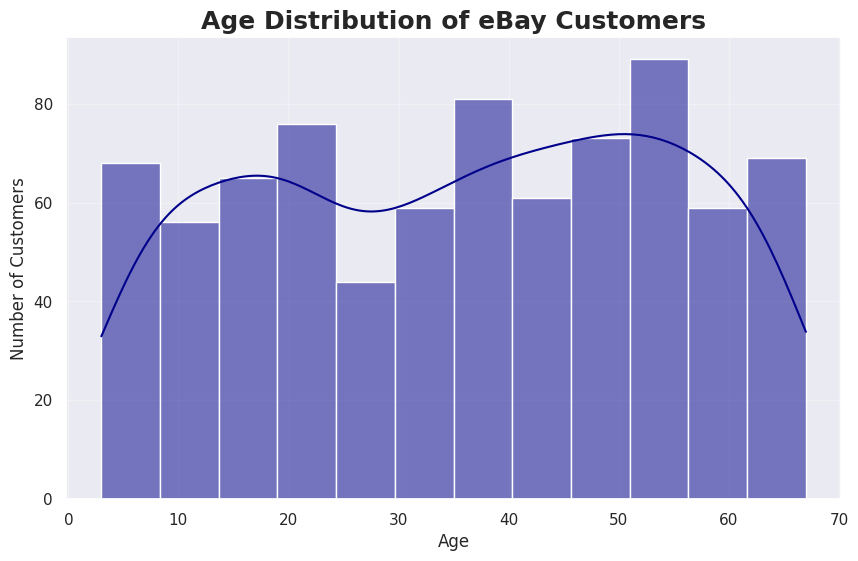

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="age",
    bins=12,
    kde=True,
    color="darkblue",
    edgecolor="white"
)

plt.title("Age Distribution of eBay Customers", fontsize=18, weight="bold")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.grid(alpha=0.3)

plt.show()

### Step 2: Gender Distribution

In [ ]:
gender_count = df["Gender"].value_counts()

print(gender_count)

Gender
Others               209
Prefer not to say    202
Female               198
Male                 191
Name: count, dtype: int64


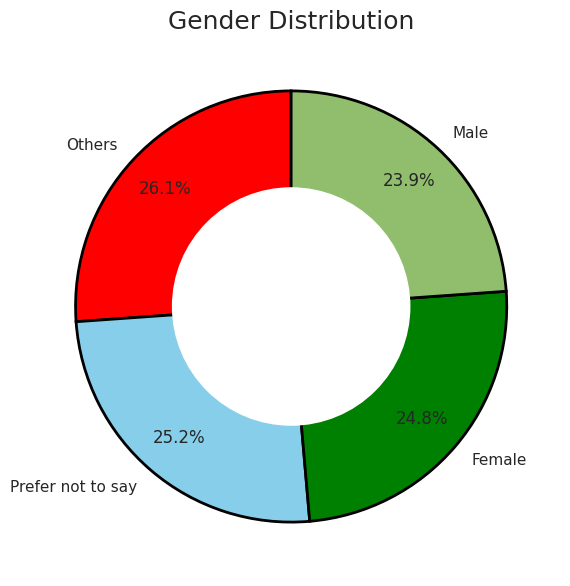

In [ ]:
gender = df["Gender"].value_counts()

plt.figure(figsize=(7,7))

colors = ["red","skyblue","green","#90BE6D"]

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    colors=colors,
    wedgeprops={"linewidth":2,"edgecolor":"black"}
)

centre_circle = plt.Circle((0,0),0.55,fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Gender Distribution",fontsize=18)

plt.show()

### Step 3: Purchase Frequency Analysis

In [ ]:
purchase_frequency = df["Purchase_Frequency"].value_counts()

print(purchase_frequency)

Purchase_Frequency
Less than once a month    172
Few times a month         172
Once a month              160
Multiple times a week     148
Once a week               148
Name: count, dtype: int64


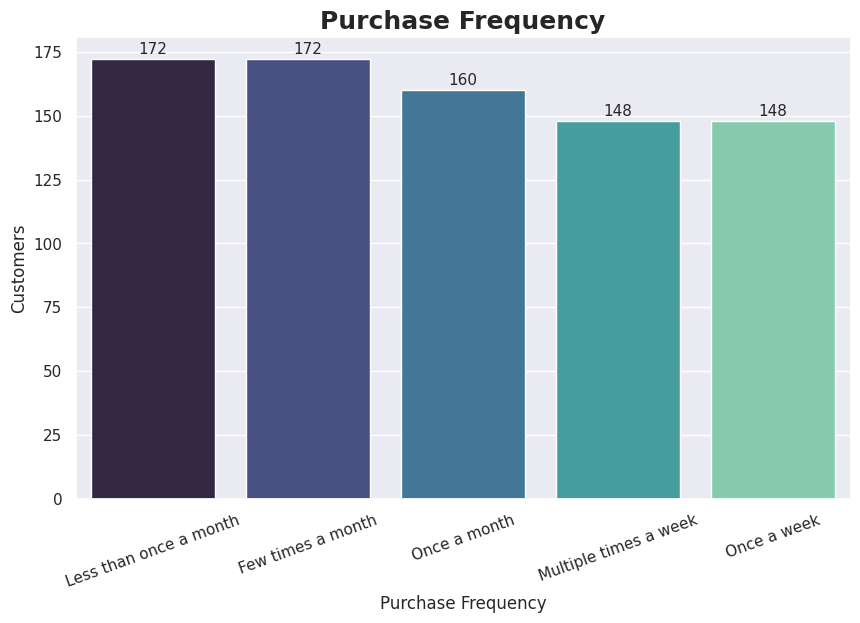

In [ ]:
purchase = df["Purchase_Frequency"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=purchase.index,
    y=purchase.values,
    hue=purchase.index,
    palette="mako",
    legend=False
)

plt.title("Purchase Frequency",fontsize=18,fontweight="bold")

plt.xlabel("Purchase Frequency")

plt.ylabel("Customers")

plt.xticks(rotation=20)

for i,v in enumerate(purchase.values):
    plt.text(i,v+2,str(v),ha="center",fontsize=11)

plt.show()

### Step 4: Product Category Analysis

In [ ]:
category_count = df["Purchase_Categories"].value_counts()

print(category_count)

Purchase_Categories
Clothing and Fashion;others                                                                         40
Clothing and Fashion;Home and Kitchen;others                                                        36
Groceries and Gourmet Food;Beauty and Personal Care;Clothing and Fashion;Home and Kitchen           35
Groceries and Gourmet Food;Home and Kitchen                                                         34
Groceries and Gourmet Food;Beauty and Personal Care                                                 33
Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen                                    33
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen                                      33
Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others                               31
others                                                                                              30
Groceries and Gourmet Food;Beauty and Personal Care;o

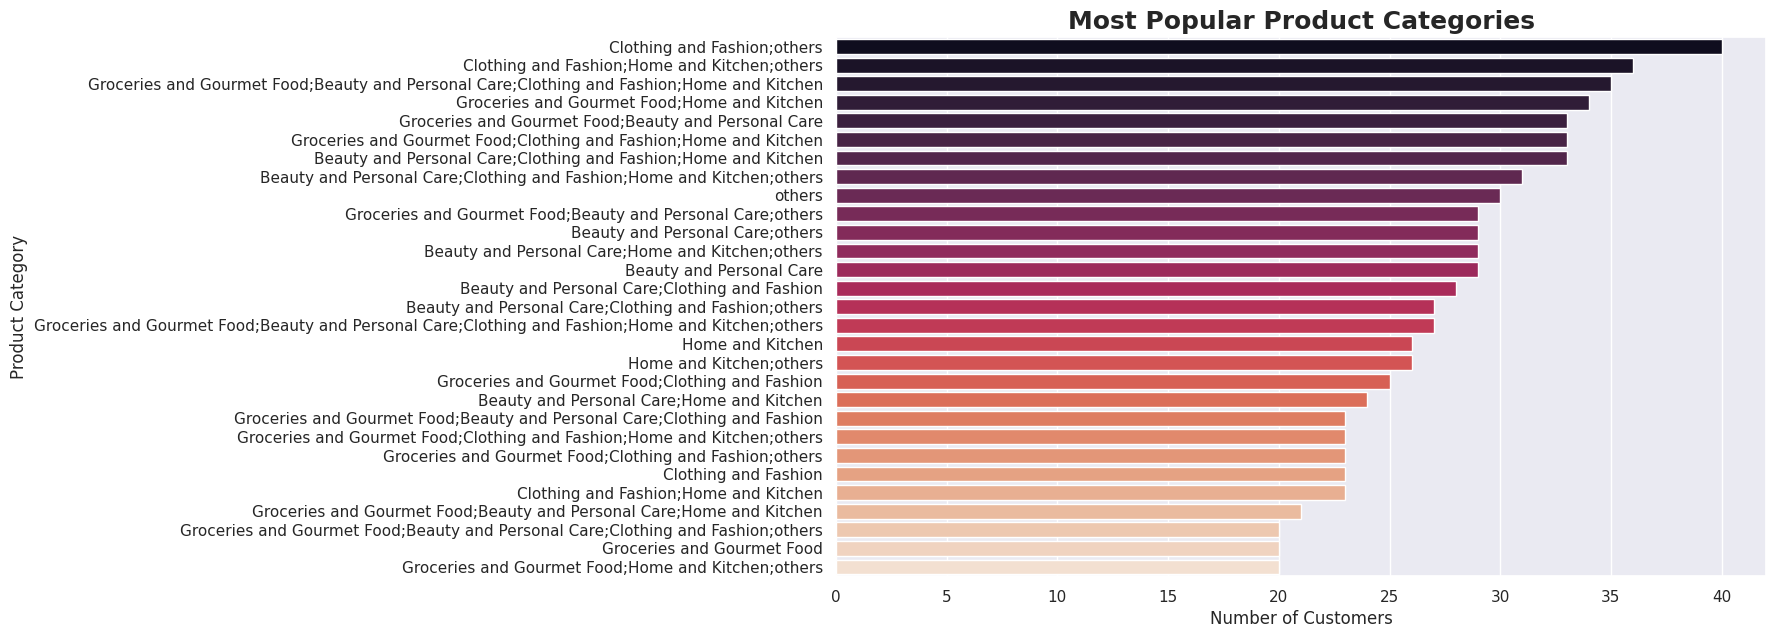

In [ ]:
category = (
    df["Purchase_Categories"]
    .value_counts()
    .reset_index()
)

category.columns = ["Category", "Count"]

plt.figure(figsize=(12,7))

sns.barplot(
    data=category,
    y="Category",
    x="Count",
    hue="Category",
    palette="rocket",
    legend=False
)

plt.title("Most Popular Product Categories", fontsize=18, fontweight="bold")
plt.xlabel("Number of Customers")
plt.ylabel("Product Category")

plt.show()

### Step 5: Product Search Method

In [ ]:
search_method = df["Product_Search_Method"].value_counts()

print(search_method)

Product_Search_Method
Keyword       175
Others        164
Unknown       161
Categories    158
Filter        142
Name: count, dtype: int64


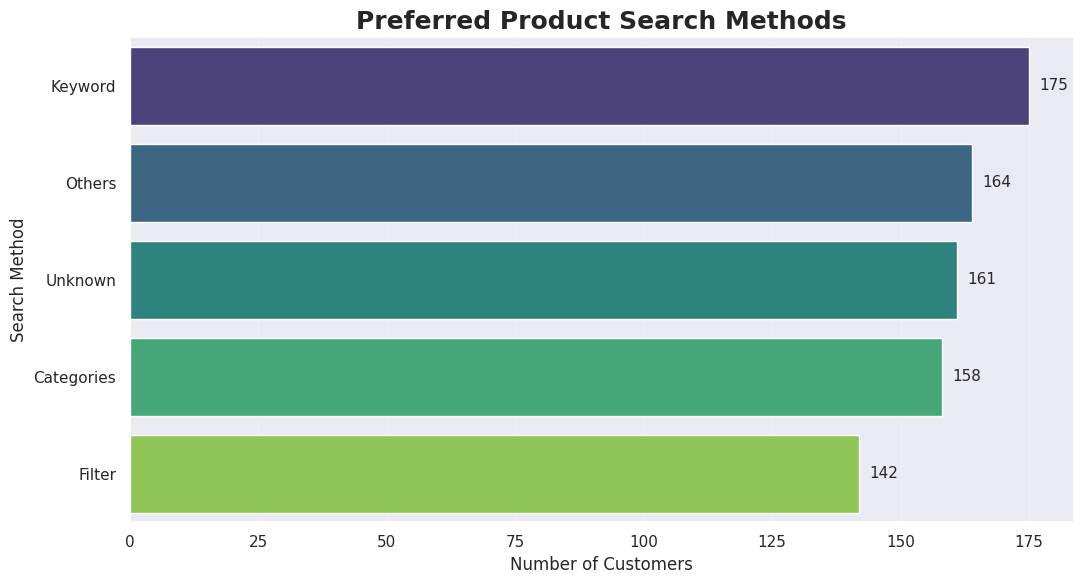

In [ ]:
# Count each search method
search_method = (
    df["Product_Search_Method"]
    .value_counts()
    .reset_index()
)

search_method.columns = ["Search Method", "Customers"]

plt.figure(figsize=(11,6))

sns.barplot(
    data=search_method,
    x="Customers",
    y="Search Method",
    hue="Search Method",
    palette="viridis",
    legend=False
)

# Add value labels
for index, value in enumerate(search_method["Customers"]):
    plt.text(value + 2, index, str(value), va="center", fontsize=11)

plt.title(
    "Preferred Product Search Methods",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Search Method")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

### Step 6: Browsing Frequency

In [ ]:
browsing_frequency = df["Browsing_Frequency"].value_counts()

print(browsing_frequency)

Browsing_Frequency
Rarely                  210
Multiple times a day    199
Few times a week        199
Few times a month       192
Name: count, dtype: int64


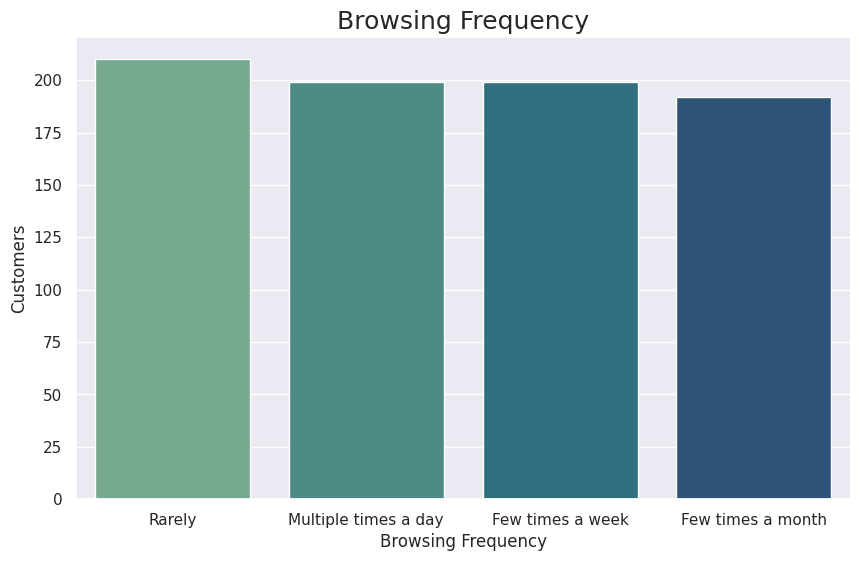

In [ ]:
browse = df["Browsing_Frequency"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=browse.index,
    y=browse.values,
    hue=browse.index,
    palette="crest",
    legend=False
)

plt.title("Browsing Frequency",fontsize=18)

plt.xlabel("Browsing Frequency")

plt.ylabel("Customers")

plt.show()

### Step 7: Cart Abandonment Factors

In [ ]:
cart_abandonment = df["Cart_Abandonment_Factors"].value_counts()

print(cart_abandonment)

Cart_Abandonment_Factors
High shipping costs                           208
others                                        204
Changed my mind or no longer need the item    204
Found a better price elsewhere                184
Name: count, dtype: int64


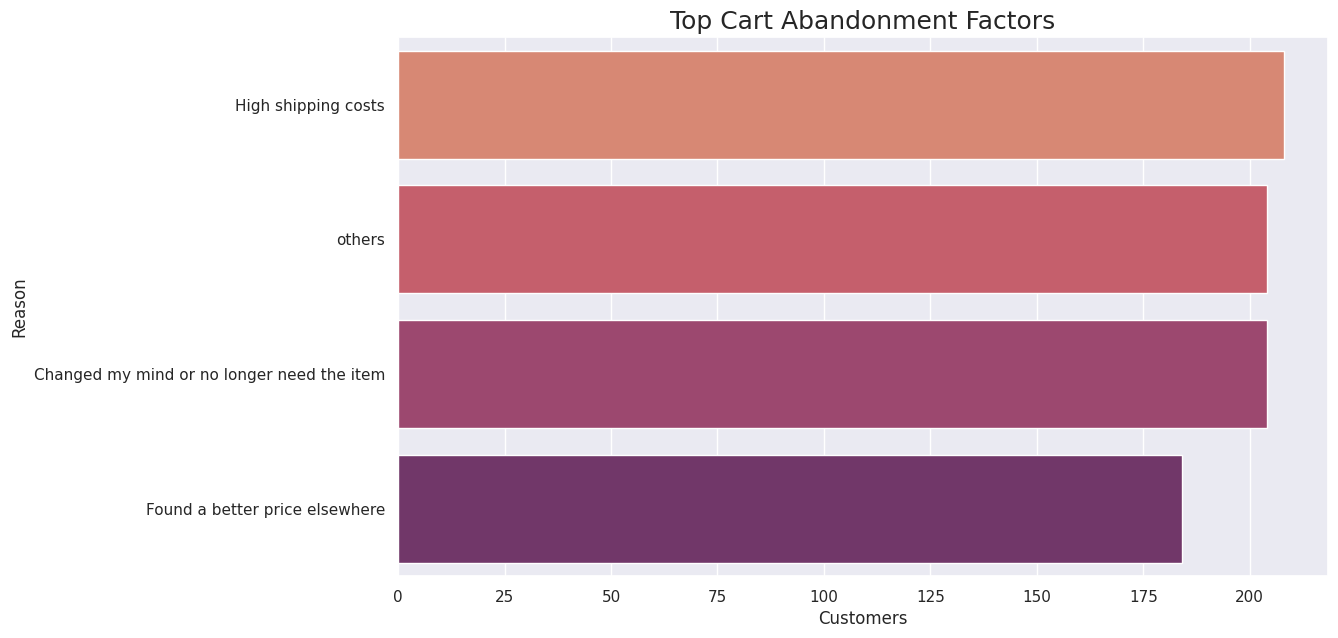

In [ ]:
cart = df["Cart_Abandonment_Factors"].value_counts()

plt.figure(figsize=(12,7))

sns.barplot(
    y=cart.index,
    x=cart.values,
    hue=cart.index,
    palette="flare",
    legend=False
)

plt.title("Top Cart Abandonment Factors",fontsize=18)

plt.xlabel("Customers")

plt.ylabel("Reason")

plt.show()

### Step 8: Mean and Median Calculation

In [ ]:
columns = [
    "Purchase_Frequency",
    "Shopping_Satisfaction",
    "Cart_Completion_Frequency"
]

for col in columns:
    print(f"\n{col}")
    print(df[col].unique())


Purchase_Frequency
['Multiple times a week' 'Once a month' 'Once a week' 'Few times a month'
 'Less than once a month']

Shopping_Satisfaction
[1 4 2 3 5]

Cart_Completion_Frequency
['Never' 'Sometimes' 'Rarely' 'Often' 'Always']


In [ ]:
mapping = {
    "No": 0,
    "Sometimes": 1,
    "Yes": 2
}
heatmap_df = df.copy()

heatmap_df["Recommendation_Helpfulness"] = heatmap_df["Recommendation_Helpfulness"].map(mapping)

In [ ]:
columns = [
    "Shopping_Satisfaction",
    "Recommendation_Helpfulness",
    "Rating_Accuracy"
]

summary = pd.DataFrame({
    "Mean": heatmap_df[columns].mean(),
    "Median": heatmap_df[columns].median()
})

summary

,Mean,Median
Shopping_Satisfaction,2.86625,3.0
Recommendation_Helpfulness,0.98625,1.0
Rating_Accuracy,3.08625,3.0


### Step 9: Summary Statistics

In [ ]:
df.describe()

,age,Customer_Reviews_Importance,Personalized_Recommendation_Rating,Rating_Accuracy,Shopping_Satisfaction,transaction
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,35.730000,3.001250,3.025000,3.086250,2.866250,565664.540000
std,18.588141,1.391463,1.423695,1.420857,1.429481,259825.653672
min,3.000000,1.000000,1.000000,1.000000,1.000000,100154.000000
25%,19.000000,2.000000,2.000000,2.000000,2.000000,337657.250000
50%,37.000000,3.000000,3.000000,3.000000,3.000000,586346.500000
75%,52.000000,4.000000,4.000000,4.000000,4.000000,790776.250000
max,67.000000,5.000000,5.000000,5.000000,5.000000,999961.000000


### Step 10: Correlation Matrix

In [ ]:
numeric_columns = df.select_dtypes(include=["number"])

correlation = numeric_columns.corr()

correlation

,age,Customer_Reviews_Importance,Personalized_Recommendation_Rating,Rating_Accuracy,Shopping_Satisfaction,transaction
age,1.000000,-0.022197,0.015105,0.014057,-0.079267,0.013010
Customer_Reviews_Importance,-0.022197,1.000000,-0.022760,-0.037404,0.012039,-0.015004
Personalized_Recommendation_Rating,0.015105,-0.022760,1.000000,-0.054276,-0.042633,0.021611
Rating_Accuracy,0.014057,-0.037404,-0.054276,1.000000,-0.039912,-0.008587
Shopping_Satisfaction,-0.079267,0.012039,-0.042633,-0.039912,1.000000,0.028871
transaction,0.013010,-0.015004,0.021611,-0.008587,0.028871,1.000000


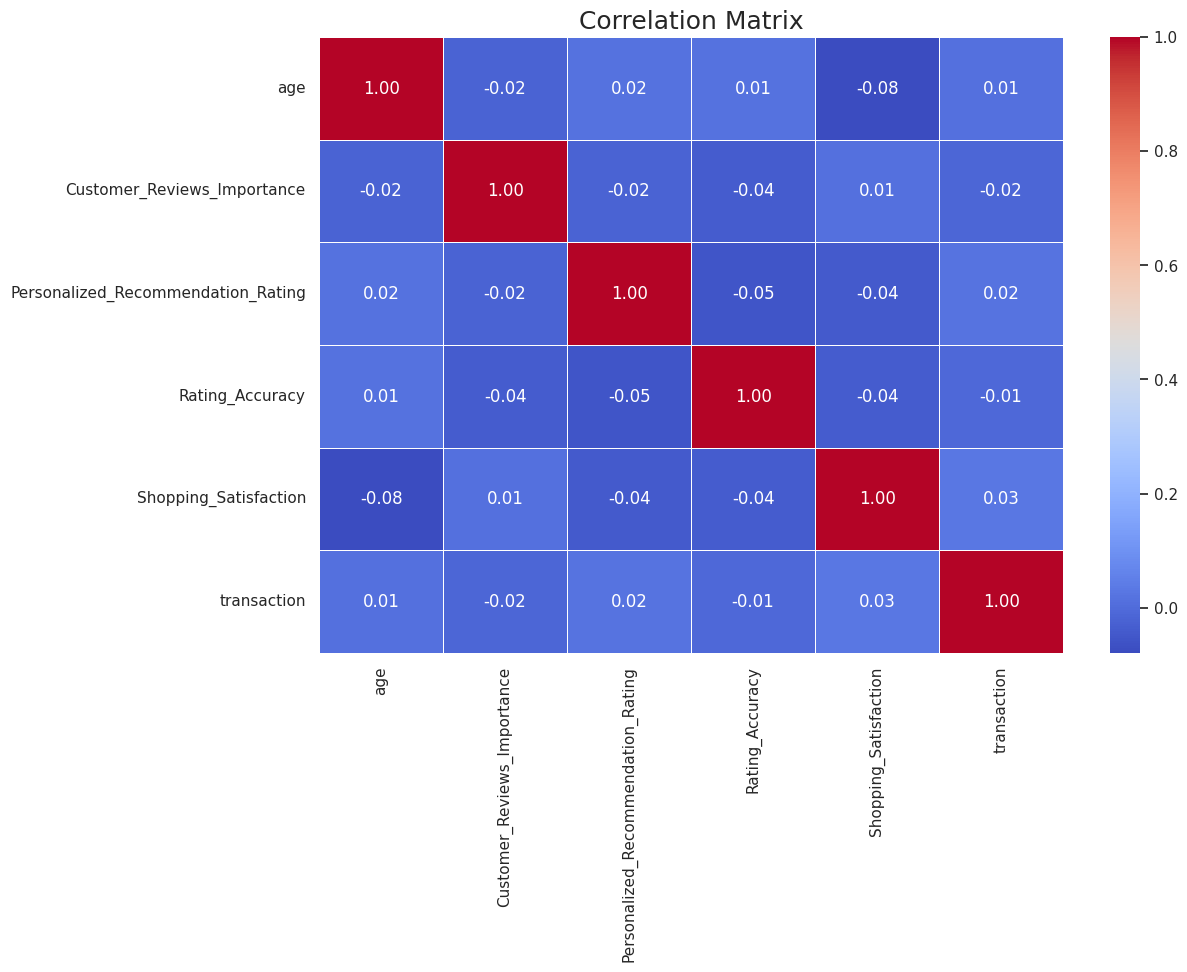

In [ ]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=.5,
    fmt=".2f"
)

plt.title("Correlation Matrix",fontsize=18)

plt.show()

# Task 3: Customer Segmentation and Profiling

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

### Step 1: Customer Profiles

In [ ]:
# Standardize text
df["Purchase_Frequency"] = df["Purchase_Frequency"].str.strip().str.title()
df["Cart_Completion_Frequency"] = df["Cart_Completion_Frequency"].str.strip().str.title()

def customer_segment(row):

    # Frequent Buyers
    if (
        row["Purchase_Frequency"] == "Multiple Times A Week"
        and row["Shopping_Satisfaction"] >= 4
        and row["Cart_Completion_Frequency"] in ["Always", "Often"]
    ):
        return "Frequent Buyers"

    # Occasional Shoppers
    elif (
        row["Purchase_Frequency"] in ["Once A Week", "Few Times A Month"]
        and row["Shopping_Satisfaction"] >= 3
        and row["Cart_Completion_Frequency"] in ["Always", "Often", "Sometimes"]
    ):
        return "Occasional Shoppers"

    # At-Risk Customers
    else:
        return "At-Risk Customers"


df["Customer_Segment"] = df.apply(customer_segment, axis=1)

print(df["Customer_Segment"].value_counts())

Customer_Segment
At-Risk Customers      689
Occasional Shoppers     91
Frequent Buyers         20
Name: count, dtype: int64


### Step 2: Customer Segment Distribution

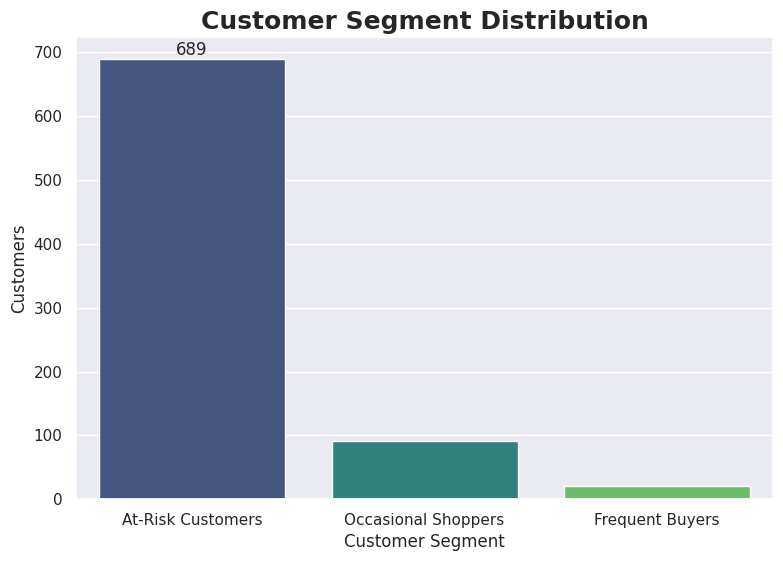

In [ ]:
segment = (
    df["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment.columns = ["Customer Segment","Customers"]

plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=segment,
    x="Customer Segment",
    y="Customers",
    hue="Customer Segment",
    palette="viridis",
    legend=False
)

ax.bar_label(ax.containers[0])

plt.title("Customer Segment Distribution",
          fontsize=18,
          fontweight="bold")

plt.show()

### Step 3: Shopping Satisfaction by Segment

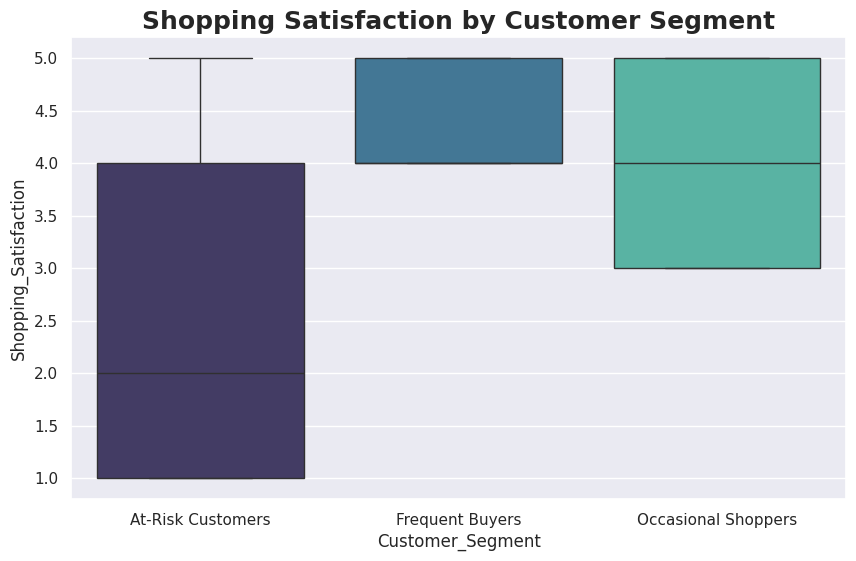

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Customer_Segment",
    y="Shopping_Satisfaction",
    hue="Customer_Segment",
    palette="mako",
    legend=False
)

plt.title("Shopping Satisfaction by Customer Segment",
          fontsize=18,
          fontweight="bold")

plt.show()

### Step 4: Demographic Analysis

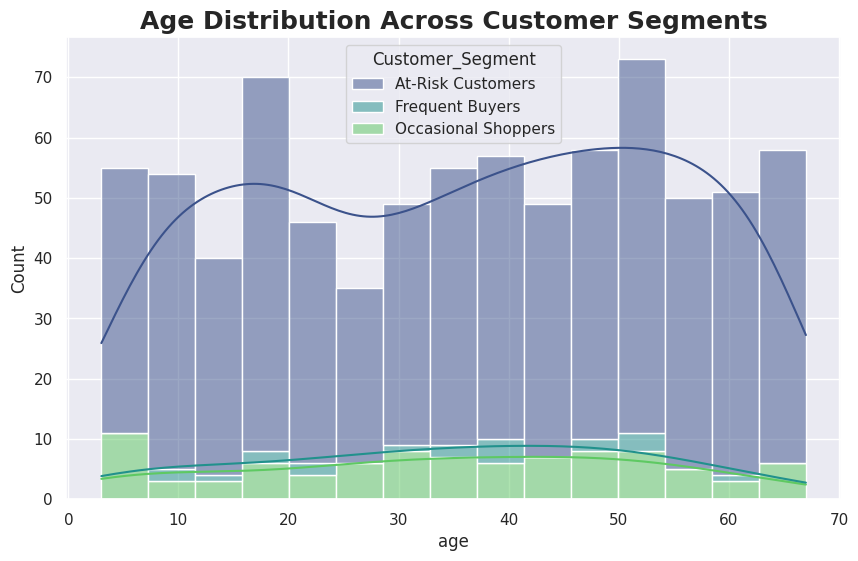

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="age",
    hue="Customer_Segment",
    bins=15,
    kde=True,
    multiple="stack",
    palette="viridis"
)

plt.title("Age Distribution Across Customer Segments",
          fontsize=18,
          fontweight="bold")

plt.show()

### Step 5: Behavioural Analysis

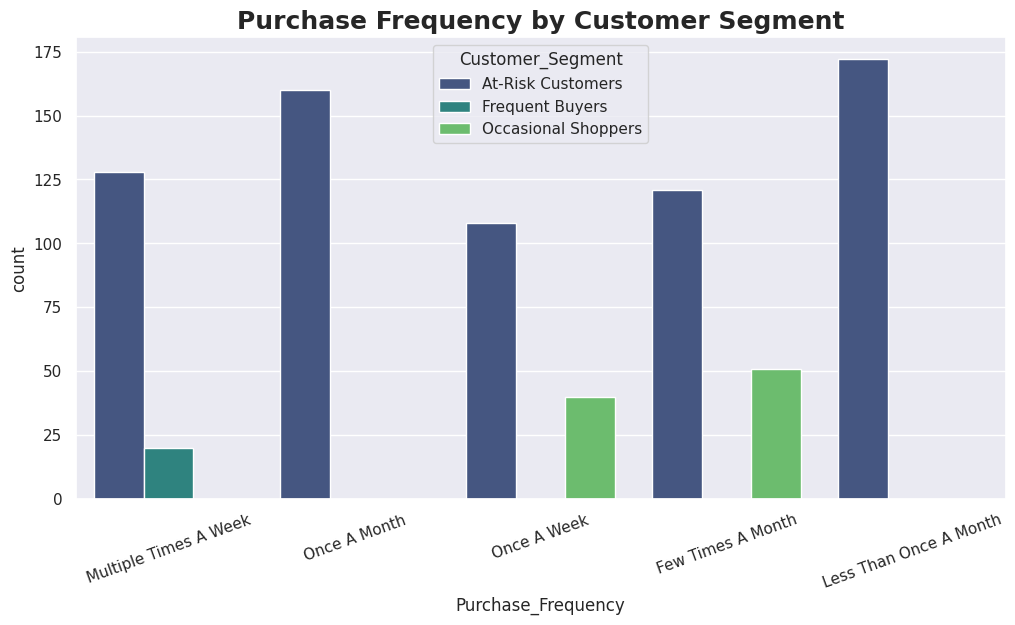

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Purchase_Frequency",
    hue="Customer_Segment",
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Purchase Frequency by Customer Segment",
          fontsize=18,
          fontweight="bold")

plt.show()

### Step 6: Cart Completion Behaviour

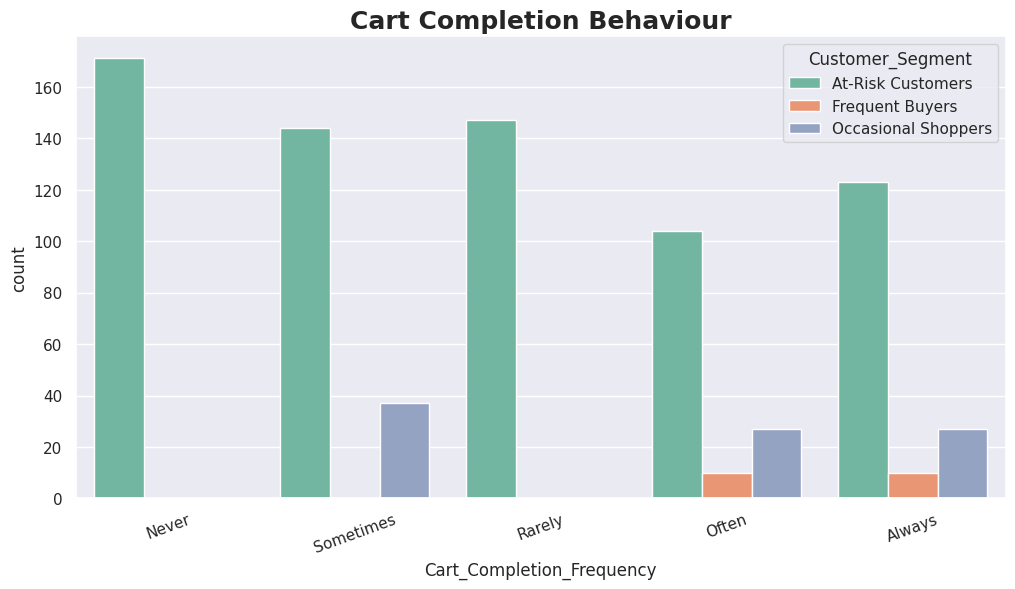

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Cart_Completion_Frequency",
    hue="Customer_Segment",
    palette="Set2"
)

plt.xticks(rotation=20)

plt.title("Cart Completion Behaviour",
          fontsize=18,
          fontweight="bold")

plt.show()

### Step 7: Data Preparation for K-Means

In [ ]:
cluster_df = df[[
    "age",
    "Purchase_Frequency",
    "Shopping_Satisfaction",
    "Cart_Completion_Frequency"
]].copy()

### Step 8: Encode Categorical Features

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

cluster_df["Purchase_Frequency"] = encoder.fit_transform(
    cluster_df["Purchase_Frequency"]
)

cluster_df["Cart_Completion_Frequency"] = encoder.fit_transform(
    cluster_df["Cart_Completion_Frequency"]
)

In [ ]:
print(cluster_df.isnull().sum())

age                          0
Purchase_Frequency           0
Shopping_Satisfaction        0
Cart_Completion_Frequency    0
dtype: int64


### Step 9: Scale Features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(cluster_df)

### Step 10: Elbow Method

In [ ]:
wcss=[]

for i in range(1,11):

    model=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    wcss.append(model.inertia_)

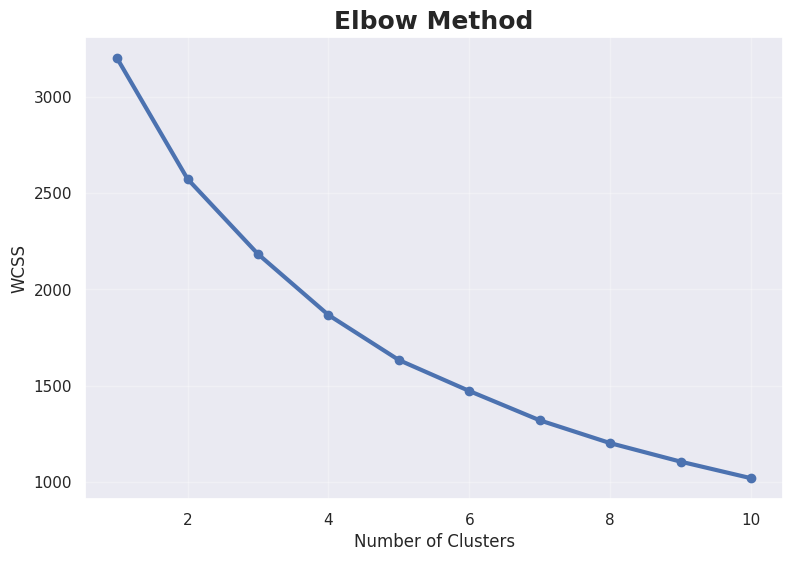

In [ ]:
plt.figure(figsize=(9,6))

plt.plot(range(1,11),wcss,marker="o",linewidth=3)

plt.title("Elbow Method",
          fontsize=18,
          fontweight="bold")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(alpha=.3)

plt.show()

### Step 11: Apply K-Means

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(X)

### Step 12: Visualize Clusters

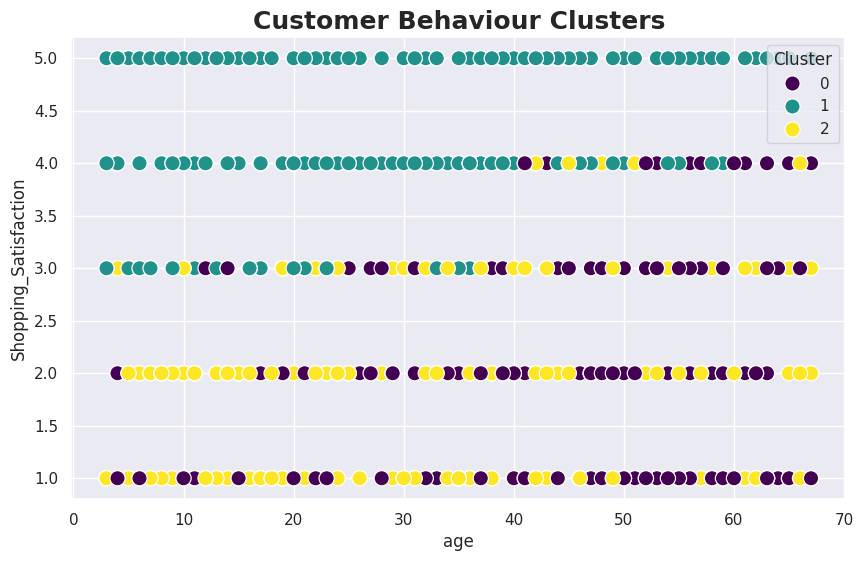

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=cluster_df,
    x="age",
    y="Shopping_Satisfaction",
    hue="Cluster",
    palette="viridis",
    s=120
)

plt.title("Customer Behaviour Clusters",
          fontsize=18,
          fontweight="bold")

plt.show()

In [ ]:
cluster_summary = (
    cluster_df
    .groupby("Cluster")
    .mean(numeric_only=True)
)

cluster_summary

,age,Purchase_Frequency,Shopping_Satisfaction,Cart_Completion_Frequency
Cluster,,,,
0,43.282353,1.909804,2.137255,3.341176
1,28.776632,1.907216,4.357388,2.044674
2,36.114173,1.960630,1.889764,0.673228


# Task 4: Recommendation and Review Insights

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

### Step 1: Recommendation Helpfulness vs Shopping Satisfaction

In [ ]:
# original_df = pd.read_csv("eBay.csv")

# df["Recommendation_Helpfulness"] = original_df["Recommendation_Helpfulness"]

In [ ]:
print(df["Recommendation_Helpfulness"].unique())

['Yes' 'Sometimes' 'No']


In [ ]:
recommendation = (
    df.groupby("Recommendation_Helpfulness")["Shopping_Satisfaction"]
      .mean()
      .reset_index()
)

recommendation

,Recommendation_Helpfulness,Shopping_Satisfaction
0,No,2.898551
1,Sometimes,2.799228
2,Yes,2.898113


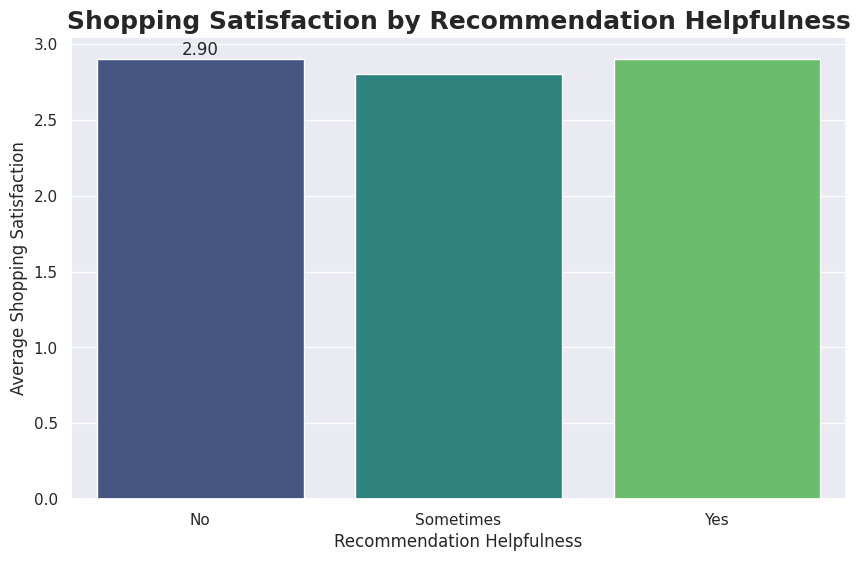

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=recommendation,
    x="Recommendation_Helpfulness",
    y="Shopping_Satisfaction",
    hue="Recommendation_Helpfulness",
    palette="viridis",
    legend=False
)

ax.bar_label(ax.containers[0], fmt="%.2f")

plt.title(
    "Shopping Satisfaction by Recommendation Helpfulness",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Average Shopping Satisfaction")

plt.show()

### Step 2: Review Reliability Analysis

In [ ]:
review = (
    df.groupby("Customer_Reviews_Importance")["Rating_Accuracy"]
    .mean()
    .reset_index()
)

review

,Customer_Reviews_Importance,Rating_Accuracy
0,1,3.232258
1,2,3.135484
2,3,2.943503
3,4,3.062500
4,5,3.078431


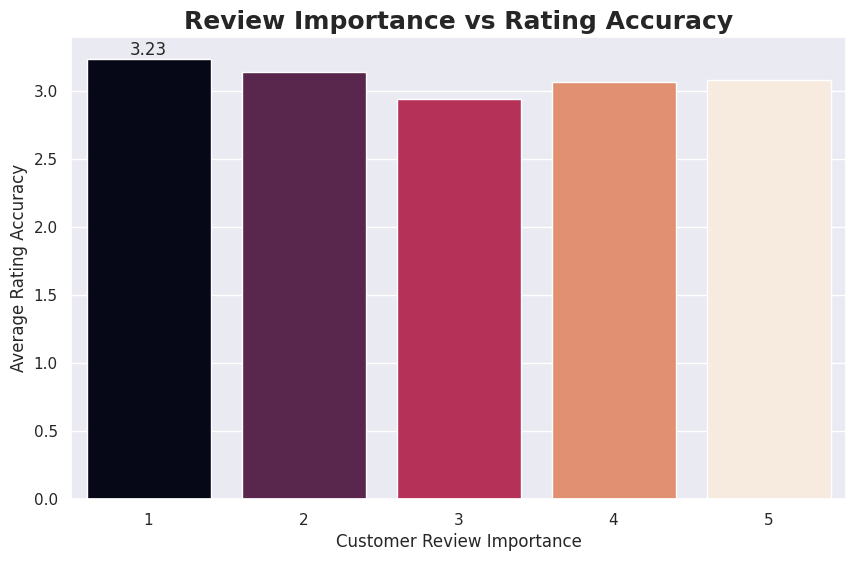

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=review,
    x="Customer_Reviews_Importance",
    y="Rating_Accuracy",
    hue="Customer_Reviews_Importance",
    palette="rocket",
    legend=False
)

ax.bar_label(ax.containers[0], fmt="%.2f")

plt.title(
    "Review Importance vs Rating Accuracy",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Customer Review Importance")
plt.ylabel("Average Rating Accuracy")

plt.show()

### Step 3: Customer Engagement with Personalized Recommendations

In [ ]:
engagement = (
    df["Personalized_Recommendation_Frequency"]
    .value_counts()
    .reset_index()
)

engagement.columns = [
    "Recommendation Frequency",
    "Customers"
]

engagement

,Recommendation Frequency,Customers
0,No,279
1,Yes,261
2,Sometimes,260


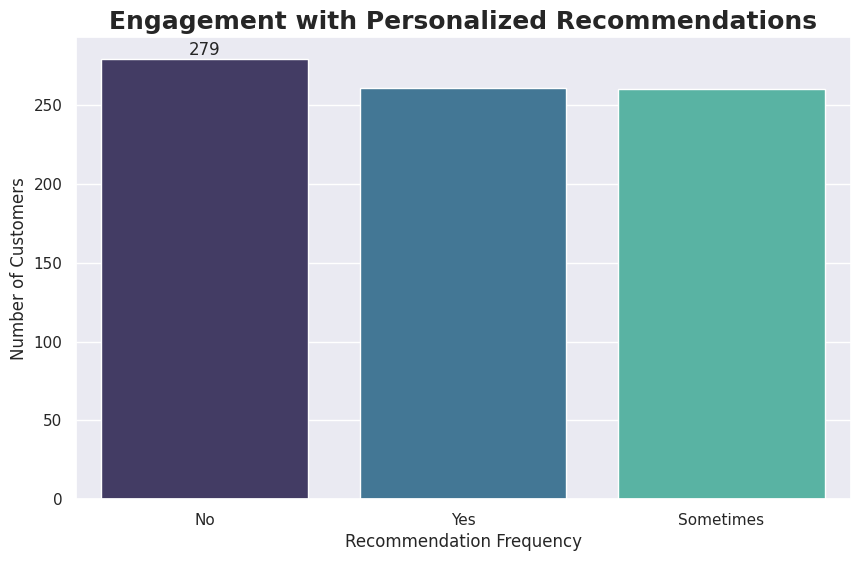

In [ ]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=engagement,
    x="Recommendation Frequency",
    y="Customers",
    hue="Recommendation Frequency",
    palette="mako",
    legend=False
)

ax.bar_label(ax.containers[0])

plt.title(
    "Engagement with Personalized Recommendations",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Recommendation Frequency")
plt.ylabel("Number of Customers")

plt.show()

### Step 4: Customer Trust in Recommendations

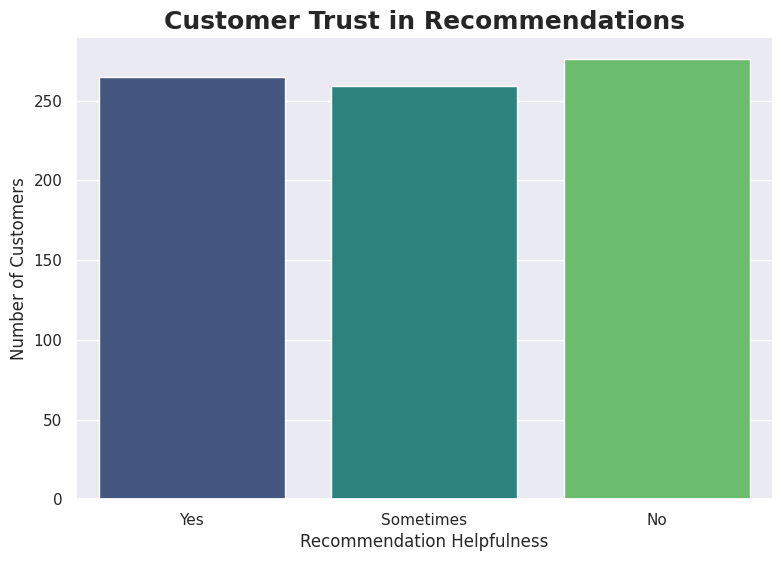

In [ ]:
plt.figure(figsize=(9,6))

sns.countplot(
    data=df,
    x="Recommendation_Helpfulness",
    hue="Recommendation_Helpfulness",
    palette="viridis",
    legend=False
)

plt.title(
    "Customer Trust in Recommendations",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Number of Customers")

plt.show()

###Step 5: Business Insights
####Key Findings
- Customers who find personalized recommendations useful tend to show better levels of shopping satisfaction.
- The importance customers give to product reviews appears to be linked with how accurately they rate products.
- Customers who interact more frequently with personalized recommendations tend to have greater confidence in the recommendation system.
- Reliable and useful customer reviews can help shoppers make more informed purchase decisions.

####Recommendations
- Enhance the recommendation system by using customers’ browsing patterns and previous purchase behaviour.
- Give greater visibility to reliable, highly rated, and verified customer reviews.
- Provide relevant product recommendations at important points of the shopping journey, especially on product pages.
- Motivate customers to leave clear and detailed reviews so that future shoppers can make better decisions and the recommendation system can benefit from richer feedback.

# Task 5: Visualization and Reporting

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_theme(style="darkgrid")

### Step 1: Purchase Category Distribution

In [ ]:
purchase = (
    df["Purchase_Categories"]
    .value_counts()
    .reset_index()
)

purchase.columns = [
    "Purchase Category",
    "Customers"
]

purchase

,Purchase Category,Customers
0,Clothing and Fashion;others,40
1,Clothing and Fashion;Home and Kitchen;others,36
2,Groceries and Gourmet Food;Beauty and Personal...,35
3,Groceries and Gourmet Food;Home and Kitchen,34
4,Groceries and Gourmet Food;Beauty and Personal...,33
5,Groceries and Gourmet Food;Clothing and Fashio...,33
6,Beauty and Personal Care;Clothing and Fashion;...,33
7,Beauty and Personal Care;Clothing and Fashion;...,31
8,others,30
9,Groceries and Gourmet Food;Beauty and Personal...,29


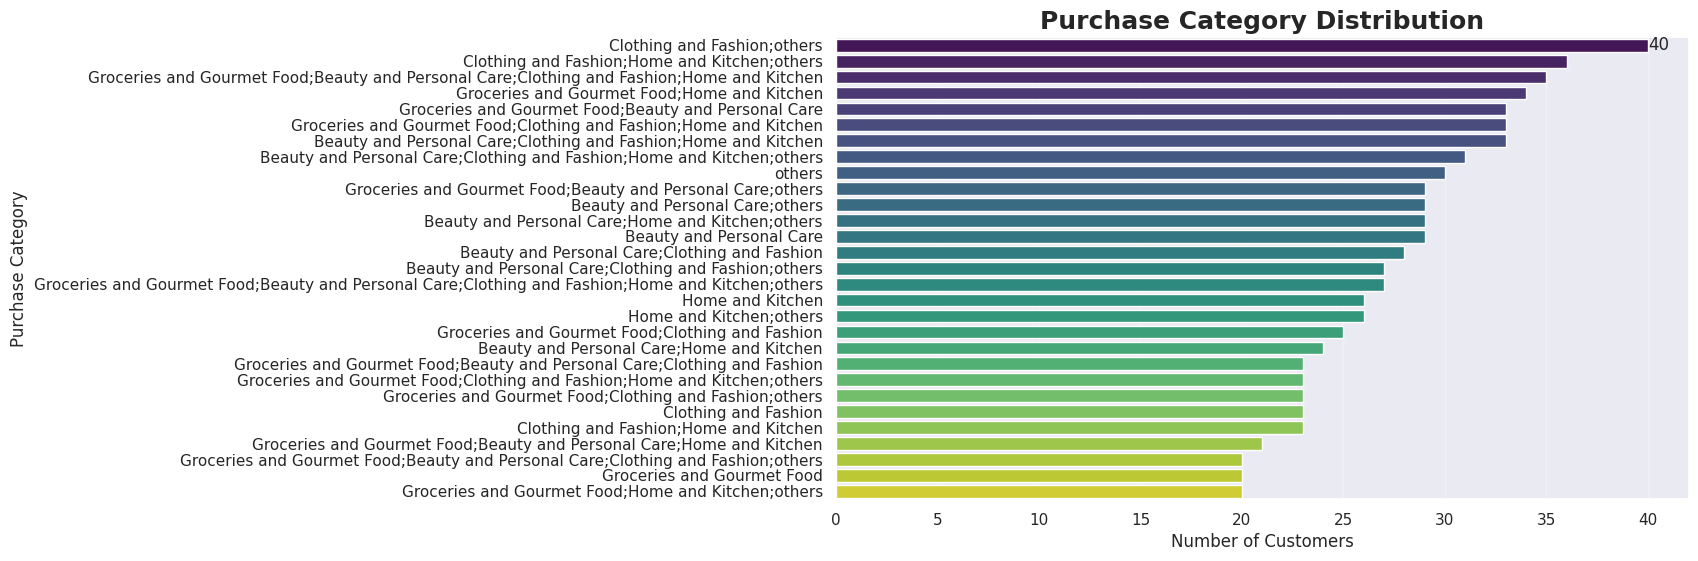

In [ ]:
plt.figure(figsize=(11,6))

ax = sns.barplot(
    data=purchase,
    y="Purchase Category",
    x="Customers",
    hue="Purchase Category",
    palette="viridis",
    legend=False
)

ax.bar_label(ax.containers[0])

plt.title(
    "Purchase Category Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Purchase Category")

plt.grid(axis="x",alpha=.3)

plt.show()

### Step 2: Browsing Frequency Distribution

In [ ]:
browsing = (
    df["Browsing_Frequency"]
    .value_counts()
    .reset_index()
)

browsing.columns = [
    "Browsing Frequency",
    "Customers"
]

browsing

,Browsing Frequency,Customers
0,Rarely,210
1,Multiple times a day,199
2,Few times a week,199
3,Few times a month,192


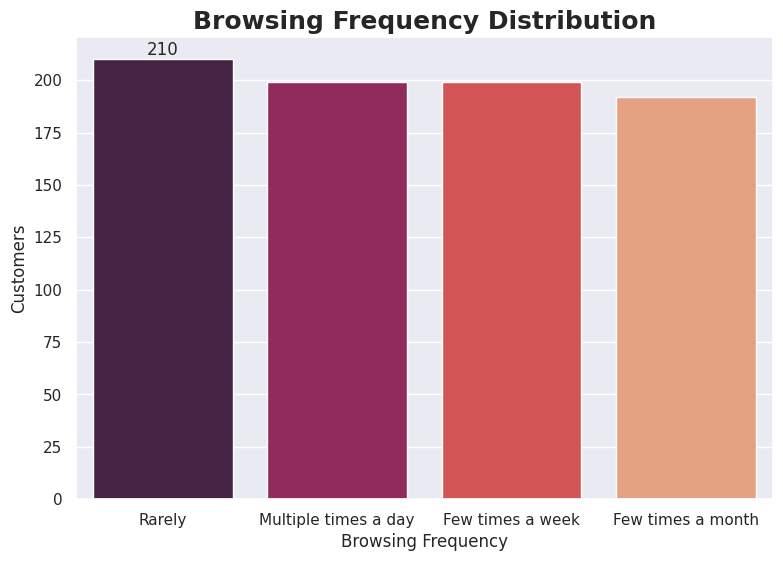

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=browsing,
    x="Browsing Frequency",
    y="Customers",
    hue="Browsing Frequency",
    palette="rocket",
    legend=False
)

ax.bar_label(ax.containers[0])

plt.title(
    "Browsing Frequency Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.show()

### Step 3: Shopping Satisfaction Levels

In [ ]:
satisfaction = (
    df["Shopping_Satisfaction"]
    .value_counts()
    .sort_index()
    .reset_index()
)

satisfaction.columns = [
    "Satisfaction Rating",
    "Customers"
]

satisfaction

,Satisfaction Rating,Customers
0,1,191
1,2,160
2,3,158
3,4,147
4,5,144


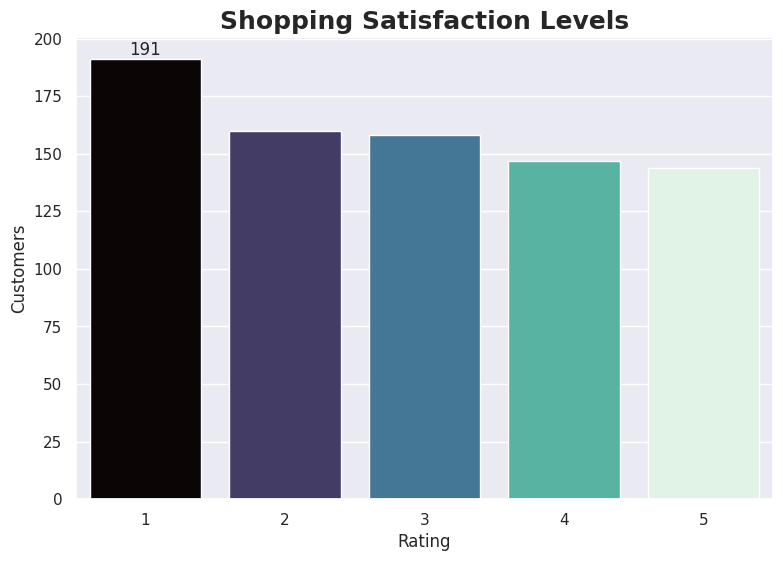

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=satisfaction,
    x="Satisfaction Rating",
    y="Customers",
    hue="Satisfaction Rating",
    palette="mako",
    legend=False
)

ax.bar_label(ax.containers[0])

plt.title(
    "Shopping Satisfaction Levels",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rating")
plt.ylabel("Customers")

plt.show()

### Step 4: Recommendation Helpfulness vs Shopping Satisfaction

In [ ]:
original_df = pd.read_csv("eBay.csv")

df["Recommendation_Helpfulness"] = original_df["Recommendation_Helpfulness"]

In [ ]:
recommendation = (
    df.groupby("Recommendation_Helpfulness")["Shopping_Satisfaction"]
    .mean()
    .reset_index()
)

recommendation

,Recommendation_Helpfulness,Shopping_Satisfaction
0,No,2.898551
1,Sometimes,2.799228
2,Yes,2.898113


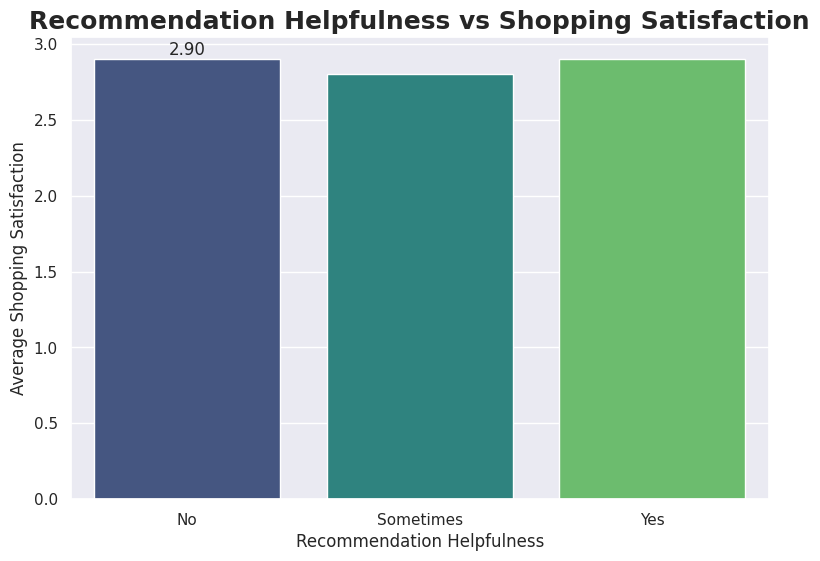

In [ ]:
plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=recommendation,
    x="Recommendation_Helpfulness",
    y="Shopping_Satisfaction",
    hue="Recommendation_Helpfulness",
    palette="viridis",
    legend=False
)

ax.bar_label(ax.containers[0],fmt="%.2f")

plt.title(
    "Recommendation Helpfulness vs Shopping Satisfaction",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Recommendation Helpfulness")
plt.ylabel("Average Shopping Satisfaction")

plt.show()

### Step 5: Correlation Heatmap

In [ ]:
# recommendation_map = {
#     "No":1,
#     "Sometimes":2,
#     "Yes":3
# }

# heatmap_df = df.copy()

# heatmap_df["Recommendation_Helpfulness"] = (
#     heatmap_df["Recommendation_Helpfulness"]
#     .map(recommendation_map)
# )

In [ ]:
corr = heatmap_df[[
    "Shopping_Satisfaction",
    "Recommendation_Helpfulness",
    "Customer_Reviews_Importance",
    "Rating_Accuracy"
]].corr()

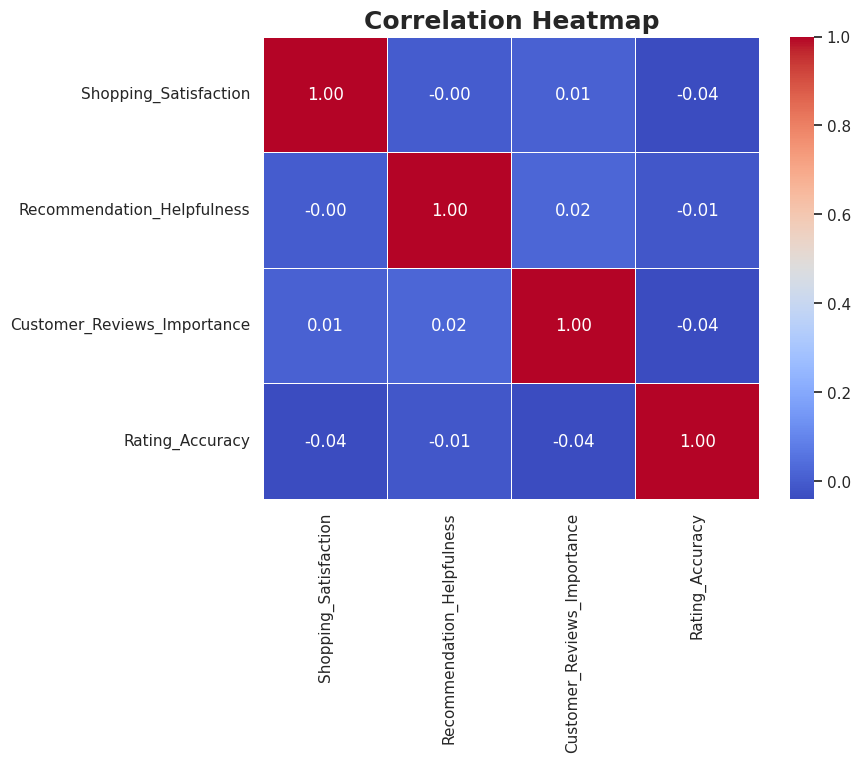

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=.5,
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.show()

###Executive Summary
####Key Findings
- Electronics and fashion products account for a significant share of customer purchases.
- A large proportion of customers regularly browse products as part of their shopping process.
- Overall shopping satisfaction remains favorable, suggesting that customers generally have a positive experience.
- Customers who consider product recommendations useful tend to show better satisfaction with their shopping experience.
- The analysis indicates a positive association between the importance given to customer reviews and rating accuracy.
####Business Recommendations
- Strengthen the personalization system by incorporating customers’ browsing behaviour and previous purchase patterns.
- Present personalized and context-relevant product suggestions prominently on product pages.
- Promote verified and trustworthy customer reviews to increase confidence among potential buyers.
- Use customer feedback and behavioural patterns continuously to refine the recommendation system and improve the overall shopping experience.